In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt
from self_consistency_k import build_bdg_hamiltonian, bdg_sc_full_k

In [3]:
t=1
mu=1.8
T = 0.01

U=0
V=1.5
V_prime=1.5

h = np.array([0, 0, 0])
Nx, Ny = 50, 50

out = bdg_sc_full_k(
    t, mu, Nx, Ny, V=V,
    temperature=T, maxiter=1000,
    verbose_free=True, atol=1e-3,rtol=0.1,
    F_init=np.array([0.1, -0.1, 0.1j, -0.1j], dtype=np.complex128),
)

print(out.corr)
print("Free_energy = ", out.free_energy)
print("s-wave =", out.F_swave)
print("d-wave =", out.F_dwave)
print("p_x    =", out.F_px)
print("p_y    =", out.F_py)

Free energy = -5578.916991631662
S = 1.3326429724742888e-96
E_S = 0.0026077007865941
Total free energy = -5578.914383930875
Corr(F0=np.complex128(9.465169669093179e-18-2.101785203669458e-17j), F_xplus=np.complex128(0.02084746502013333-4.315421108023847e-18j), F_xmin=np.complex128(-0.02084746502013335+6.883413245862072e-18j), F_yplus=np.complex128(-2.794361692991937e-18+0.020847465020133384j), F_ymin=np.complex128(-1.3838400775767132e-19-0.0208474650201333j), Fuu_xplus=np.complex128(5.2542176797478825e-20-1.278376353987267e-19j), Fuu_xmin=np.complex128(1.20590086865849e-19+1.0753768701011809e-19j), Fuu_yplus=np.complex128(7.672426107501306e-20-2.1228752293971786e-20j), Fuu_ymin=np.complex128(1.5825367487716258e-19+4.4884583443171886e-20j), Fdd_xplus=np.complex128(7.443361950728387e-19-3.9944959211775355e-19j), Fdd_xmin=np.complex128(1.4954144546613261e-18+2.0035227265745915e-18j), Fdd_yplus=np.complex128(-1.0701319417517857e-18-4.2571583981124316e-19j), Fdd_ymin=np.complex128(1.54753579

In [9]:
t=1
mu=1.8
T = 0.01

Bz = np.linspace(0, 1.5, 20)
Free_parr = np.zeros(len(Bz))
Free_narr = np.zeros(len(Bz))

U=0
V=1.5
V_prime=1.5

Nx, Ny = 20, 100

for i, B in enumerate(Bz):
    h = np.array([0, 0, B])
    normal = bdg_sc_full_k(
        t, mu, Nx, Ny, V=V, h=h,
        temperature=T, maxiter=1000,
        verbose_free=True, atol=1e-3,rtol=0.1,
    ) 
    pwave = bdg_sc_full_k(
        t, mu, Nx, Ny, V=V, h=h,
        temperature=T, maxiter=1000,
        verbose_free=True, atol=1e-3,rtol=0.1,
        F_init=np.array([0.1, -0.1, 0.1j, -0.1j], dtype=np.complex128),
    )
    Free_parr[i] = pwave.free_energy
    Free_narr[i] = normal.free_energy

Free energy = -4456.812118502118
S = 1.5094444939406126e-93
E_S = 0.0
Total free energy = -4456.812118502118
Free energy = -4463.179048965307
S = 1.4930414934123246e-93
E_S = 0.002761771357547291
Total free energy = -4463.176287193949
Free energy = -4458.2459810398595
S = 2.025013201510175e-90
E_S = 0.0
Total free energy = -4458.2459810398595
Free energy = -4458.245981039859
S = 2.0250132015105207e-90
E_S = 2.1553854509444596e-25
Total free energy = -4458.245981039859
Free energy = -4462.598571435104
S = 5.433359548549746e-87
E_S = 0.0
Total free energy = -4462.598571435104
Free energy = -4462.598571435104
S = 5.433359548550209e-87
E_S = 1.1309854453392575e-25
Total free energy = -4462.598571435104
Free energy = -4470.1753713561975
S = 1.4578374137253516e-83
E_S = 0.0
Total free energy = -4470.1753713561975
Free energy = -4470.1753713561975
S = 1.4578374137255172e-83
E_S = 2.60612697800164e-26
Total free energy = -4470.1753713561975
Free energy = -4480.403653529337
S = 3.91155767599576

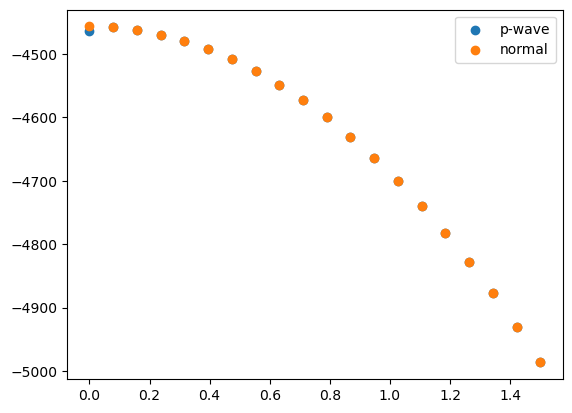

In [11]:
plt.scatter(Bz, Free_parr, label="p-wave")
plt.scatter(Bz, Free_narr, label="normal")
plt.legend()

In [ ]:
t=1
mu=0.8
T = 0.01

U=0
V=1.5
V_prime=1.5

h = np.array([0, 0, 0])
Nx, Ny = 50, 50

out = bdg_sc_full_k(
    t, mu, Nx, Ny, V_prime=V_prime,
    temperature=T, maxiter=1000,
    verbose=True, atol=1e-3,rtol=0.1,
    Fuu_init=np.array([0.1, -0.1, 0.1, -0.1], dtype=np.complex128),
    Fdd_init=np.array([0.1, -0.1, 0.1, -0.1], dtype=np.complex128)
)

print(out["corr"])
print("Free_energy = ", out["free_energy"])
print("s-wave =", out["F_swave"])
print("d-wave =", out["F_dwave"])
print("p_x    =", out["F_px"])
print("p_y    =", out["F_py"])

F0:
old = 0j
new = -8.982339119953008e-20j
abs error = 8.982339119953008e-20
rel error = 8.982339119953008e-08
F_xplus:
old = 0j
new = (1.5482962661637775e-19+8.936819841932782e-21j)
abs error = 1.550873303240923e-19
rel error = 1.550873303240923e-07
F_xmin:
old = 0j
new = (-1.5482962661637775e-19+8.936819841932782e-21j)
abs error = 1.550873303240923e-19
rel error = 1.550873303240923e-07
F_yplus:
old = 0j
new = (1.548296266163777e-19+8.93681984193277e-21j)
abs error = 1.5508733032409224e-19
rel error = 1.5508733032409225e-07
F_ymin:
old = 0j
new = (-1.548296266163777e-19+8.93681984193277e-21j)
abs error = 1.5508733032409224e-19
rel error = 1.5508733032409225e-07
Fuu_xplus:
old = (0.1+0j)
new = (0.06736279740356264+7.525040703407204e-18j)
abs error = 0.03263720259643736
rel error = 0.32637202596110987
Fuu_xmin:
old = (-0.1+0j)
new = (-0.06736279740356264+7.525040703407204e-18j)
abs error = 0.03263720259643736
rel error = 0.32637202596110987
Fuu_yplus:
old = (0.1+0j)
new = (0.06736279740

: 

In [ ]:
temps = np.concatenate([
    np.arange(0.001, 0.020 + 1e-12, 0.001),
    np.arange(0.021, 0.060 + 1e-12, 0.0005),
])

init_states = np.array([[0.1, -0.1, 0j, 0j],
                        [0, 0, -0.1j, -0.1j],
                        [0.1, -0.1, 0.1j, -0.1j],
                        [0.1, -0.1, 0.1, -0.1],
                        [0.1, 0.1, -0.1, -0.1],
                        [0.1, 0.1, 0.1, 0.1]], 
                        dtype=np.complex128)

t=1
mu=1.8

U=0
V=1.5
V_prime=1.5

h = np.array([0, 0, 0])
Nx, Ny = 30, 30

s_arr = np.zeros_like(temps, dtype=np.complex128)
d_arr = np.zeros_like(temps, dtype=np.complex128)
px_arr = np.zeros_like(temps, dtype=np.complex128)
py_arr = np.zeros_like(temps, dtype=np.complex128)

for i, temp in enumerate(temps):
    out = bdg_sc_full_k(
        t, mu, Nx, Ny, V=V,
        temperature=temp, maxiter=1000,
        verbose=False, atol=1e-3,rtol=0.1,
        F_init=np.array([0.1, -0.1, 0.1j, -0.1j], dtype=np.complex128),
    )
    s_arr[i] = out["F_swave"]
    d_arr[i] = out["F_dwave"]
    px_arr[i] = out["F_px"]
    py_arr[i] = out["F_py"]
    print(f"Temperature {i+1}= {temp:.4f}")

Temperature 1= 0.0010
Temperature 2= 0.0020
Temperature 3= 0.0030
Temperature 4= 0.0040
Temperature 5= 0.0050
Temperature 6= 0.0060
Temperature 7= 0.0070
Temperature 8= 0.0080
Temperature 9= 0.0090
Temperature 10= 0.0100
Temperature 11= 0.0110
Temperature 12= 0.0120
Temperature 13= 0.0130
Temperature 14= 0.0140
Temperature 15= 0.0150
Temperature 16= 0.0160
Temperature 17= 0.0170
Temperature 18= 0.0180
Temperature 19= 0.0190
Temperature 20= 0.0200
Temperature 21= 0.0210
Temperature 22= 0.0215
Temperature 23= 0.0220
Temperature 24= 0.0225
Temperature 25= 0.0230
Temperature 26= 0.0235
Temperature 27= 0.0240
Temperature 28= 0.0245
Temperature 29= 0.0250
Temperature 30= 0.0255
Temperature 31= 0.0260
Temperature 32= 0.0265
Temperature 33= 0.0270
Temperature 34= 0.0275
Temperature 35= 0.0280
Temperature 36= 0.0285
Temperature 37= 0.0290
Temperature 38= 0.0295
Temperature 39= 0.0300
Temperature 40= 0.0305
Temperature 41= 0.0310
Temperature 42= 0.0315
Temperature 43= 0.0320
Temperature 44= 0.03

: 

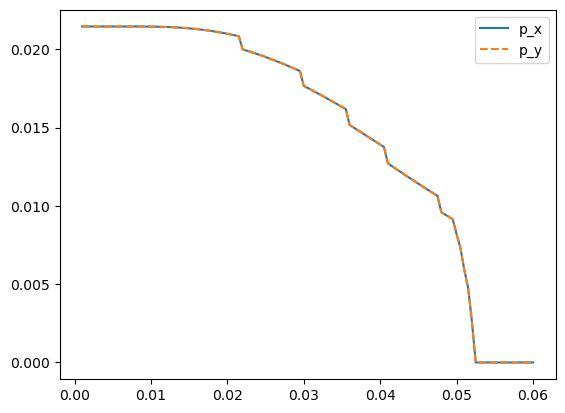

: 

In [ ]:
# plt.plot(temps, s_arr.real, label="s-wave")
# plt.plot(temps, d_arr.real, label="d-wave")
plt.plot(temps, px_arr.real, label="p_x")
plt.plot(temps, py_arr.imag,'--', label="p_y")
plt.legend()

In [ ]:
temps = np.concatenate([
    np.arange(0.001, 0.22 + 1e-12, 0.005),
    np.arange(0.20, 0.30 + 1e-12, 0.002),
])
print(len(temps))
init_states = np.array([[0.1, -0.1, 0j, 0j],
                        [0, 0, -0.1j, -0.1j],
                        [0.1, -0.1, 0.1j, -0.1j],
                        [0.1, -0.1, 0.1, -0.1],
                        [0.1, 0.1, -0.1, -0.1],
                        [0.1, 0.1, 0.1, 0.1]], 
                        dtype=np.complex128)

t=1
mu=0.5

U=0
V=1.5
V_prime=1.5

h = np.array([0, 0, 0])
Nx, Ny = 30, 30

s_arr = np.zeros_like(temps, dtype=np.complex128)
d_arr = np.zeros_like(temps, dtype=np.complex128)
px_arr = np.zeros_like(temps, dtype=np.complex128)
py_arr = np.zeros_like(temps, dtype=np.complex128)

for i, temp in enumerate(temps):
    out = bdg_sc_full_k(
        t, mu, Nx, Ny, V=V,
        temperature=temp, maxiter=1000,
        verbose=False, atol=1e-3,rtol=0.1,
        F_init=np.array([0.1, 0.1, -0.1, -0.1], dtype=np.complex128),
    )
    s_arr[i] = out["F_swave"]
    d_arr[i] = out["F_dwave"]
    px_arr[i] = out["F_px"]
    py_arr[i] = out["F_py"]
    print(f"Temperature {i+1}= {temp:.4f}")

95
Temperature 1= 0.0010
Temperature 2= 0.0060
Temperature 3= 0.0110
Temperature 4= 0.0160
Temperature 5= 0.0210
Temperature 6= 0.0260
Temperature 7= 0.0310
Temperature 8= 0.0360
Temperature 9= 0.0410
Temperature 10= 0.0460
Temperature 11= 0.0510
Temperature 12= 0.0560
Temperature 13= 0.0610
Temperature 14= 0.0660
Temperature 15= 0.0710
Temperature 16= 0.0760
Temperature 17= 0.0810
Temperature 18= 0.0860
Temperature 19= 0.0910
Temperature 20= 0.0960
Temperature 21= 0.1010
Temperature 22= 0.1060
Temperature 23= 0.1110
Temperature 24= 0.1160
Temperature 25= 0.1210
Temperature 26= 0.1260
Temperature 27= 0.1310
Temperature 28= 0.1360
Temperature 29= 0.1410
Temperature 30= 0.1460
Temperature 31= 0.1510
Temperature 32= 0.1560
Temperature 33= 0.1610
Temperature 34= 0.1660
Temperature 35= 0.1710
Temperature 36= 0.1760
Temperature 37= 0.1810
Temperature 38= 0.1860
Temperature 39= 0.1910
Temperature 40= 0.1960
Temperature 41= 0.2010
Temperature 42= 0.2060
Temperature 43= 0.2110
Temperature 44= 0

: 

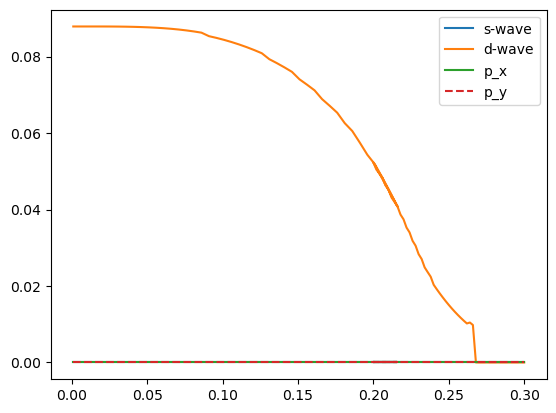

: 

In [ ]:
plt.plot(temps, s_arr.real, label="s-wave")
plt.plot(temps, d_arr.real, label="d-wave")
plt.plot(temps, px_arr.real, label="p_x")
plt.plot(temps, py_arr.imag,'--', label="p_y")
plt.legend()